# Bank Loan Performance Analysis
## Understanding loan quality, risk, and repayment trends

**Goal:** Analyze 38,576 loan applications to identify performance KPIs, 
good vs bad loan patterns, and trends that drive business decisions.

**Dataset:** Financial Loan Data | 38,576 records | 25 features  
**Tools:** Python, pandas, matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv('../Data/financial_loan.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (38576, 25)

Columns: ['id_no', 'address_state', 'application_type', 'emp_length', 'emp_title', 'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date', 'last_payment_date', 'Good_Bad_Loan', 'loan_status', 'next_payment_date', 'member_id', 'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income', 'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc', 'total_payment']

First 3 rows:


,id_no,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.00,0.01,59.83,0.15,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.00,0.05,109.43,0.19,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.00,0.21,421.65,0.16,12000,11,3522


In [4]:
print(df.columns.tolist())

['id_no', 'address_state', 'application_type', 'emp_length', 'emp_title', 'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date', 'last_payment_date', 'Good_Bad_Loan', 'loan_status', 'next_payment_date', 'member_id', 'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income', 'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc', 'total_payment']


## Step 1: Core KPI Dashboard

The 5 headline metrics every bank loan analyst tracks daily.

In [5]:
total_applications  = len(df)
total_funded        = df['loan_amount'].sum()
total_received      = df['total_payment'].sum()
avg_interest_rate   = df['int_rate'].mean() * 100
avg_dti             = df['dti'].mean() * 100

print("=" * 50)
print("BANK LOAN PERFORMANCE — CORE KPIs")
print("=" * 50)
print(f"Total Loan Applications : {total_applications:,}")
print(f"Total Funded Amount     : ${total_funded:,.0f}")
print(f"Total Amount Received   : ${total_received:,.0f}")
print(f"Net Position            : ${total_received - total_funded:,.0f}")
print(f"Avg Interest Rate       : {avg_interest_rate:.2f}%")
print(f"Avg DTI Ratio           : {avg_dti:.2f}%")

BANK LOAN PERFORMANCE — CORE KPIs
Total Loan Applications : 38,576
Total Funded Amount     : $435,757,075
Total Amount Received   : $473,070,933
Net Position            : $37,313,858
Avg Interest Rate       : 12.05%
Avg DTI Ratio           : 13.33%


In [6]:
good_bad = df.groupby('Good_Bad_Loan').agg(
    applications  = ('id_no', 'count'),
    funded_amount = ('loan_amount', 'sum'),
    received      = ('total_payment', 'sum')
).reset_index()

good_bad['pct_applications'] = (good_bad['applications'] / total_applications * 100).round(2)
good_bad['avg_loan']         = (good_bad['funded_amount'] / good_bad['applications']).round(0)

print("=== GOOD vs BAD LOAN BREAKDOWN ===")
print(good_bad.to_string(index=False))

bad_funded = good_bad[good_bad['Good_Bad_Loan']=='Bad Loan']['funded_amount'].values[0]
print(f"\nTotal exposure from Bad Loans : ${bad_funded:,.0f}")
print(f"Recovery rate on Bad Loans    : {good_bad[good_bad['Good_Bad_Loan']=='Bad Loan']['received'].values[0]/bad_funded*100:.1f}%")

=== GOOD vs BAD LOAN BREAKDOWN ===
Good_Bad_Loan  applications  funded_amount  received  pct_applications  avg_loan
     Bad Loan          5333       65532225  37284763             13.82  12288.00
    Good Loan         33243      370224850 435786170             86.18  11137.00

Total exposure from Bad Loans : $65,532,225
Recovery rate on Bad Loans    : 56.9%


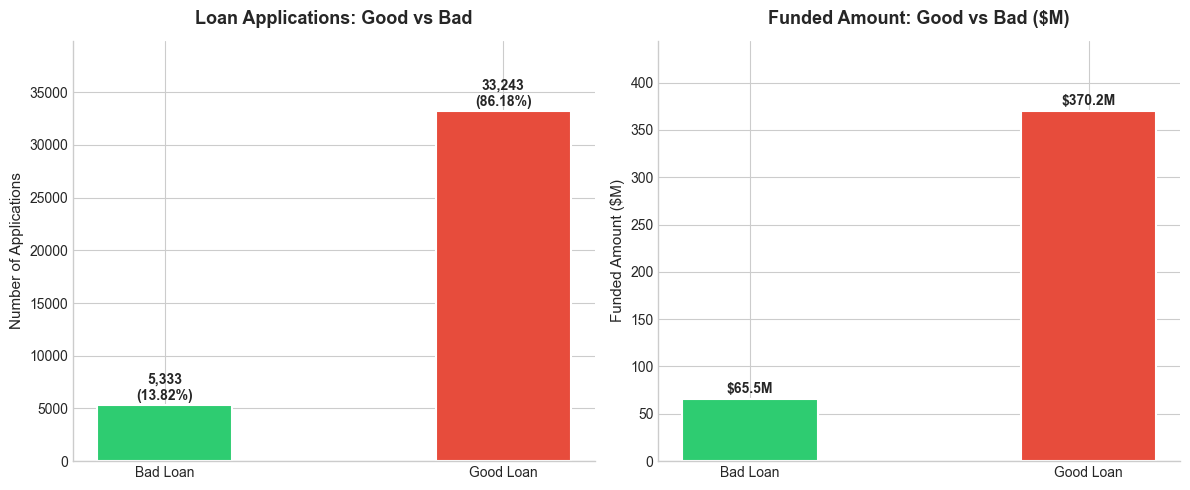

Chart saved!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2ECC71', '#E74C3C']

bars = axes[0].bar(good_bad['Good_Bad_Loan'], good_bad['applications'],
                   color=colors, width=0.4, edgecolor='white', linewidth=1.5)
for bar, (_, row) in zip(bars, good_bad.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"{row['applications']:,}\n({row['pct_applications']}%)",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Loan Applications: Good vs Bad', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Number of Applications', fontsize=11)
axes[0].set_ylim(0, good_bad['applications'].max() * 1.2)
axes[0].spines[['top', 'right']].set_visible(False)

bars2 = axes[1].bar(good_bad['Good_Bad_Loan'],
                    good_bad['funded_amount']/1e6,
                    color=colors, width=0.4, edgecolor='white', linewidth=1.5)
for bar, (_, row) in zip(bars2, good_bad.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 row['funded_amount']/1e6 + 3,
                 f"${row['funded_amount']/1e6:.1f}M",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Funded Amount: Good vs Bad ($M)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel('Funded Amount ($M)', fontsize=11)
axes[1].set_ylim(0, good_bad['funded_amount'].max()/1e6 * 1.2)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../Images/01_good_vs_bad_loans.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [8]:
df['issue_date'] = pd.to_datetime(df['issue_date'], format='%d-%m-%Y')
df['Month']      = df['issue_date'].dt.to_period('M')

monthly = df.groupby('Month').agg(
    applications  = ('id_no', 'count'),
    funded_amount = ('loan_amount', 'sum')
).reset_index()

monthly['Month_str']  = monthly['Month'].astype(str)
monthly['MoM_apps']   = monthly['applications'].pct_change() * 100
monthly['MoM_funded'] = monthly['funded_amount'].pct_change() * 100

print("=== MONTHLY TREND ===")
print(monthly[['Month_str','applications','funded_amount',
               'MoM_apps','MoM_funded']].to_string(index=False))

last_month = monthly.iloc[-1]
print(f"\nMTD Applications  : {last_month['applications']:,}")
print(f"MoM Change        : {last_month['MoM_apps']:+.1f}%")
print(f"MTD Funded Amount : ${last_month['funded_amount']:,.0f}")
print(f"MoM Funded Change : {last_month['MoM_funded']:+.1f}%")

=== MONTHLY TREND ===
Month_str  applications  funded_amount  MoM_apps  MoM_funded
  2021-01          2332       25031650       NaN         NaN
  2021-02          2279       24647825     -2.27       -1.53
  2021-03          2627       28875700     15.27       17.15
  2021-04          2755       29800800      4.87        3.20
  2021-05          2911       31738350      5.66        6.50
  2021-06          3184       34161475      9.38        7.63
  2021-07          3366       35813900      5.72        4.84
  2021-08          3441       38149600      2.23        6.52
  2021-09          3536       40907725      2.76        7.23
  2021-10          3796       44893800      7.35        9.74
  2021-11          4035       47754825      6.30        6.37
  2021-12          4314       53981425      6.91       13.04

MTD Applications  : 4,314
MoM Change        : +6.9%
MTD Funded Amount : $53,981,425
MoM Funded Change : +13.0%


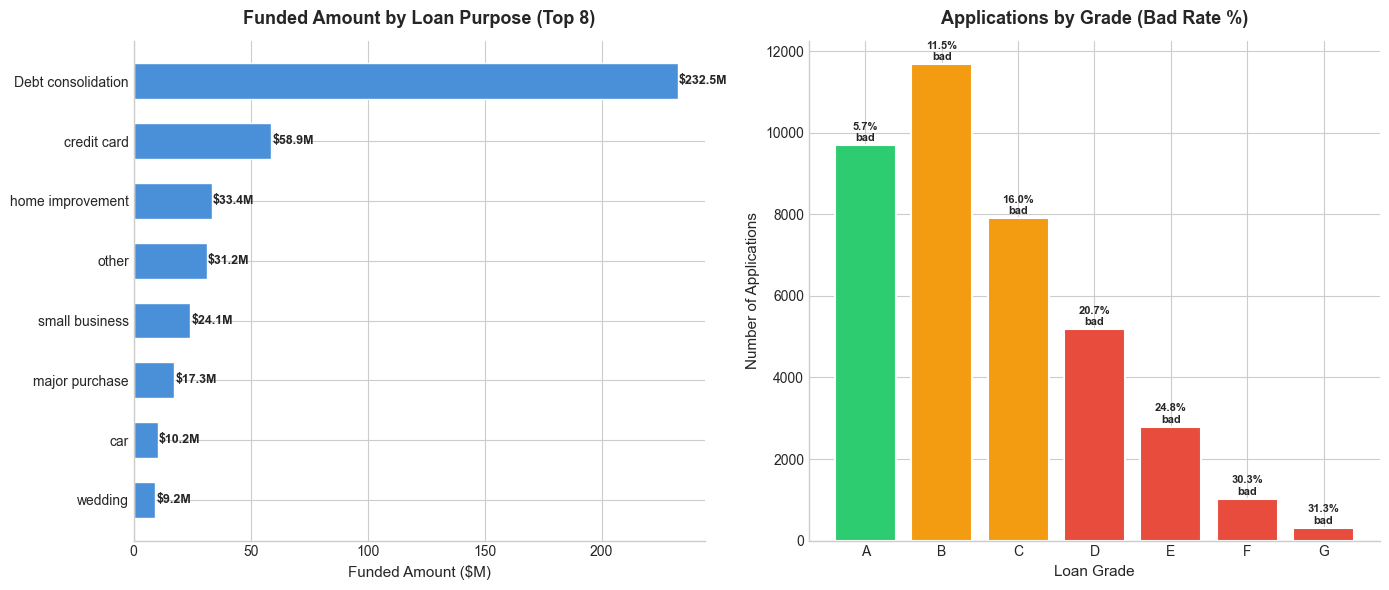

Chart saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Top 8 purposes
purpose_stats = df.groupby('purpose')['loan_amount'].sum().sort_values(ascending=True).tail(8)
axes[0].barh(purpose_stats.index, purpose_stats.values/1e6,
             color='#4A90D9', edgecolor='white', height=0.6)
for i, (idx, val) in enumerate(purpose_stats.items()):
    axes[0].text(val/1e6 + 0.5, i, f'${val/1e6:.1f}M',
                 va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Funded Amount by Loan Purpose (Top 8)',
                  fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Funded Amount ($M)', fontsize=11)
axes[0].spines[['top', 'right']].set_visible(False)

# Chart 2: Grade distribution
grade_stats = df.groupby('grade').agg(
    count    = ('id_no', 'count'),
    bad_rate = ('Good_Bad_Loan', lambda x: (x=='Bad Loan').mean()*100)
).reset_index().sort_values('grade')

color_grade = ['#2ECC71' if r < 10 else '#F39C12' if r < 20 else '#E74C3C'
               for r in grade_stats['bad_rate']]
bars = axes[1].bar(grade_stats['grade'], grade_stats['count'],
                   color=color_grade, edgecolor='white', linewidth=1.5)
for bar, (_, row) in zip(bars, grade_stats.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{row['bad_rate']:.1f}%\nbad",
                 ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1].set_title('Applications by Grade (Bad Rate %)',
                  fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Loan Grade', fontsize=11)
axes[1].set_ylabel('Number of Applications', fontsize=11)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../Images/03_purpose_and_grade.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

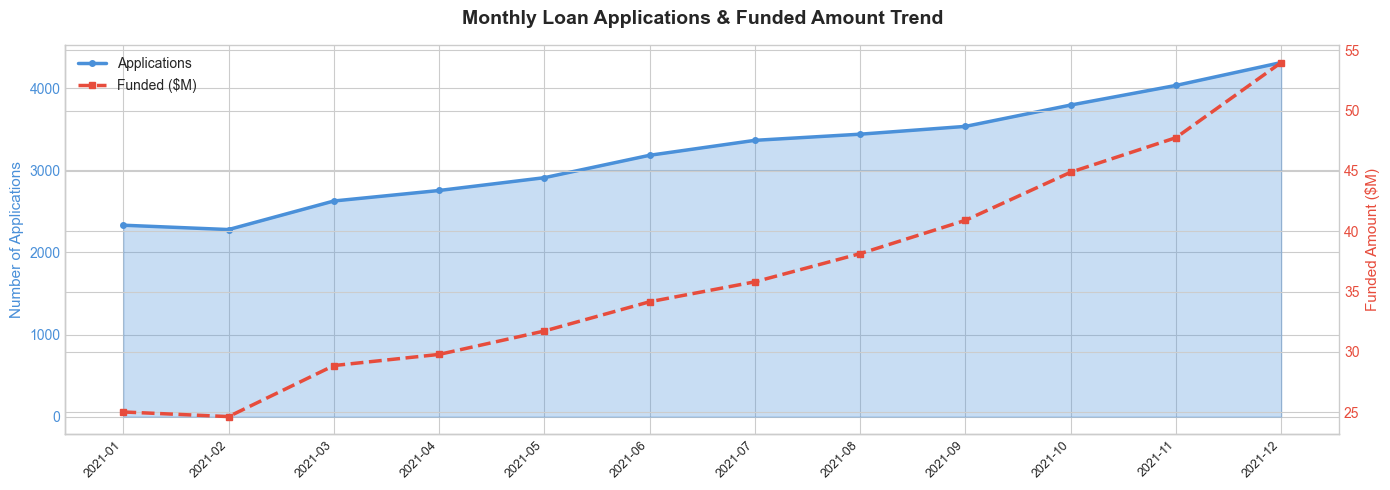

Chart saved!


In [10]:
fig, ax1 = plt.subplots(figsize=(14, 5))

x = range(len(monthly))
ax1.fill_between(x, monthly['applications'], alpha=0.3, color='#4A90D9')
ax1.plot(x, monthly['applications'], color='#4A90D9', linewidth=2.5,
         marker='o', markersize=4, label='Applications')
ax1.set_ylabel('Number of Applications', fontsize=11, color='#4A90D9')
ax1.tick_params(axis='y', labelcolor='#4A90D9')
ax1.set_xticks(x)
ax1.set_xticklabels(monthly['Month_str'], rotation=45, ha='right', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(x, monthly['funded_amount']/1e6, color='#E74C3C', linewidth=2.5,
         marker='s', markersize=4, linestyle='--', label='Funded ($M)')
ax2.set_ylabel('Funded Amount ($M)', fontsize=11, color='#E74C3C')
ax2.tick_params(axis='y', labelcolor='#E74C3C')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper left')

ax1.set_title('Monthly Loan Applications & Funded Amount Trend',
              fontsize=14, fontweight='bold', pad=15)
ax1.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../Images/02_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Step 4: Business Recommendations

### Key Findings

| Metric | Value |
|--------|-------|
| Total Loan Applications | 38,576 |
| Total Funded Amount | 435.8M |
| Total Amount Received | 473.1M |
| Net Position | +37.3M |
| Avg Interest Rate | 12.05% |
| Avg DTI | 13.33% |
| Good Loan Rate | 86.18% — 33,243 loans |
| Bad Loan Rate | 13.82% — 5,333 loans |
| Bad Loan Exposure | 65.5M |
| Recovery Rate on Bad Loans | 56.9% |


### 3 Business Recommendations

**Recommendation 1 — Tighten underwriting for Grade D-G loans**
Grade D has a 20.7% bad rate, Grade E 24.8%, Grade F 30.3%, and Grade G 31.3%.
These 4 grades represent significant default risk totaling thousands of charged-off accounts.
Action: Implement stricter DTI thresholds (below 15%) and income verification
requirements for Grade D-G applicants to reduce the $65.5M bad loan exposure.

**Recommendation 2 — Focus growth on Debt Consolidation segment**
Debt consolidation accounts for $232.5M — 53% of all funded loans — and has
only a 5.7% bad rate in Grade A which is far below average.
Action: Marketing should prioritize debt consolidation for new customer
acquisition campaigns, especially targeting Grade A-B applicants.

**Recommendation 3 — Reduce 60-month term exposure**
26.8% of loan volume (10,339 loans) is on 60-month terms which historically
carries higher default risk than 36-month loans.
Action: Incentivize shorter 36-month terms with a 0.5% interest rate reduction
to improve portfolio quality and reduce long-term default exposure.

---
*Analysis by: Parshwa Gandhi*
